# New models: Opus 5 and GPT-5.6

The paper's four outcome tables and its process-based figure, for Claude Code with Opus 5
and Codex with GPT-5.6 (September sweep, v5 max prompt, 8 datasets × 3 trials).
Process ratings are the combined supervised judges — a mistake only where both judges
flag one — the same judges that score every other condition.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# The house style, same as the other notebooks.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

import outcome_analysis as ot
from ratings import add_combined, conditions, experiments, load_condition_ratings, summary_table
from ratings.analysis.loading import DATASET_ORDER

# Claude Code + Opus 5, Codex + GPT-5.6
NEW_ARMS = tuple((a + experiments.NEW_MODELS, "full") for a in ("claude-code", "codex"))
df = ot.load(arms=NEW_ARMS)
print(f"{len(df)} trials | arms {[ot.arm_label(a) for a in NEW_ARMS]}")

# Runs the agent failed outright (no converted data): counted as failing every
# metric in the summary, instead of dropping out. See the note in section 1.
FAILED = {("sosa2024", "claude-code" + experiments.NEW_MODELS, "full", 2)}

48 trials | arms ['Claude Code Opus 5', 'Codex GPT 5.6']


## 1. Summary

**One failed trial.** Claude Code (Opus 5) Sosa2024 trial 2 produced no converted data.
Its sample conversion ran fine, but the full conversion stopped on the agent's own
consistency check: in 10 of the 152 sessions the imaging and behavioral data differ by
one frame. The agent diagnosed the mismatch, but its session ended 17 minutes in, while it
was stopping the failed run, before it fixed the code or wrote any output. It is the
agent's failure, not the harness's, so it counts as failing every metric here
(`FAILED`): Sosa24 reads 11/15, 10/15, 12/18, 2/3. The detailed tables below show its
cells as "--". The ‡ markers and footnotes are in `latex_new_agents.tex`.

In [2]:
display(Markdown(ot.summary_table(df, fmt="markdown", arms=NEW_ARMS, failed=FAILED)))
# transposed, as in latex_new_agents.tex
print(ot.summary_table_transposed(df, arms=NEW_ARMS, failed=FAILED,
                                  label="outcome_summary_new"))

| Dataset | Agent | Checks | Statistics | Decoder | End-to-end |
|---|---|---|---|---|---|
| Allen2P | Claude 5 | 10/12 | 6/15 | 6/15 | 0/3 |
|  | Codex 5.6 | 9/12 | 6/15 | 0/15 | 0/3 |
| Lee2025 | Claude 5 | 15/15 | 12/15 | 3/3 | 0/3 |
|  | Codex 5.6 | 15/15 | 12/15 | 3/3 | 0/3 |
| Majnik2025 | Claude 5 | 15/15 | 9/9 | 3/3 | 3/3 |
|  | Codex 5.6 | 15/15 | 9/9 | 3/3 | 3/3 |
| Sosa2024 | Claude 5 | 11/15 | 10/15 | 12/18 | 2/3 |
|  | Codex 5.6 | 15/15 | 14/15 | 6/18 | 0/3 |
| Chen2024 | Claude 5 | 15/15 | 9/15 | 12/12 | 1/3 |
|  | Codex 5.6 | 15/15 | 15/15 | 9/12 | 0/3 |
| Hasnain2024 | Claude 5 | 14/15 | 6/15 | 17/18 | 0/3 |
|  | Codex 5.6 | 14/15 | 2/15 | 9/18 | 0/3 |
| Zhang2025 (IBL) | Claude 5 | 15/15 | 13/15 | 12/12 | 1/3 |
|  | Codex 5.6 | 15/15 | 13/15 | 7/12 | 1/3 |
| Zhong2025 | Claude 5 | 12/15 | 10/15 | 10/12 | 0/3 |
|  | Codex 5.6 | 14/15 | 11/15 | 12/12 | 0/3 |

\begin{table}[b]
\centering
\small
\begin{NiceTabular}{l c c c c c c c c}[
  cell-space-top-limit = 1pt,
  cell-space-bottom-limit = 1pt,
  colortbl-like
]
\CodeBefore
  \rowcolors{2}{}{rowgray}
\Body
\toprule
 & Allen2P & Lee25 & Majnik25 & Sosa24 & Chen24 & Hasnain24 & Zhang25 & Zhong25 \\
\midrule
Checks
& \makecell{\textcolor{highGreen}{10/12}\\\textcolor{highGreen}{9/12}}
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{11/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{14/15}\\\textcolor{highGreen}{14/15}}
& \makecell{\textcolor{highGreen}{15/15}\\\textcolor{highGreen}{15/15}}
& \makecell{\textcolor{highGreen}{12/15}\\\textcolor{highGreen}{14/15}}
\\
Statistics
& \makecell{6/15\\6/15}
& \makecell{\textcolor{highGreen}{12/15}\\\textcolor{highGreen}{12/15}}
& \mak

## 2. Checks

The paper table's two footnotes (Lee2025 input naming, Chen2024/Hasnain2024 class counts)
describe its runs, not these, so the markers and footnotes are left out.

In [3]:
# the paper caption up to its footnotes
checks_caption = ot.CHECKS_CAPTION.split(r" \vspace{5pt}")[0]
print(ot.checks_table(df, arms=NEW_ARMS, notes={}, caption=checks_caption,
                      label="tab:checks-new"))

% requires \usepackage{booktabs, multirow, xcolor, amssymb}
\newcommand{\markbox}[1]{\makebox[1.15em][c]{#1}}
\newcommand{\ckpass}{\markbox{\textcolor{green!55!black}{\checkmark}}}
\newcommand{\ckfail}{\markbox{\textcolor{red!70!black}{$\times$}}}
\newcommand{\ckna}{\markbox{--}}

\begin{table}[htb]
\centering
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.25}
\begin{tabular}{l l ccccc}
\toprule
Dataset & Agent & Files & Format & Inputs & Outputs & N classes \\
\midrule
\multirow{2}{*}{Allen2P} & Claude 5 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckna\ckna\ckna & \ckpass\ckpass\ckpass & \ckpass\ckfail\ckfail \\
 & Codex 5.6 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckna\ckna\ckna & \ckpass\ckpass\ckpass & \ckfail\ckfail\ckfail \\
\midrule
\multirow{2}{*}{Lee2025} & Claude 5 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass \\
 & Codex 5.6 & \ckpass\ckpass\ckpass & \ckpass\ckpass\ckpass &

## 3. Dataset statistics

In [4]:
print(ot.scale_table(df, arms=NEW_ARMS, label="scale-new"))

\begin{table}[!ht]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code Opus 5} & \multicolumn{3}{c}{Codex GPT 5.6} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Metric & T1 & T2 & T3 & T1 & T2 & T3 &  \\
\midrule
\multirow{5}{*}{Allen2P} & Sessions & \textcolor{red}{0.699} & \textcolor{orange}{0.725} & \textcolor{red}{0.699} & \textcolor{red}{0.699} & \textcolor{red}{0.699} & \textcolor{orange}{0.843} & 236 \\
 & Trials & \textcolor{red}{0.596} & \textcolor{red}{0.617} & \textcolor{red}{0.595} & \textcolor{red}{0.596} & \textcolor{red}{0.596} & \textcolor{red}{0.687} & 71,242 \\
 & Subjects & 1.000 & 1.027 & 1.000 & 1.000 & 1.000 & 1.027 & 37 \\
 & Neurons & \textcolor{red}{0.696} & \textcolor{orange}{0.705} & \textcolor{red}{0.696} & \textcolor{red}{0.696} & \textcolor{red}{0.696} & \textcolor{orange}{0.705} & 41,390 \\
 & T median & 0.995 & 0.995 & 0.995 & 0.995 & 0.995 & 0.960 & 265.2 \\
\midrule
\multir

## 4. Decoder

In [5]:
print(ot.decoder_table(df, arms=NEW_ARMS, label="decoder-new"))

\begin{table}[!ht]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrr rrr c}
\toprule
 & & \multicolumn{3}{c}{Claude Code Opus 5} & \multicolumn{3}{c}{Codex GPT 5.6} & Reference \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Dataset & Variable & T1 & T2 & T3 & T1 & T2 & T3 & (Chance) \\
\midrule
\multirow{5}{*}{Allen2P} & trial\_outcome & \textcolor{red}{0.921} & \textcolor{red}{0.937} & \textcolor{red}{0.932} & \textcolor{red}{0.815} & \textcolor{red}{0.815} & \textcolor{red}{0.833} & 0.323 (0.250) \\
 & running\_speed & \textcolor{red}{0.806} & \textcolor{red}{0.803} & \textcolor{red}{0.809} & \textcolor{red}{0.623} & \textcolor{red}{0.623} & \textcolor{red}{0.636} & 0.350 (0.200) \\
 & pupil\_diameter & \textcolor{red}{0.608} & \textcolor{red}{0.614} & \textcolor{red}{0.615} & \textcolor{red}{0.493} & \textcolor{red}{0.493} & \textcolor{red}{0.509} & 0.433 (0.200) \\
 & image\_name & \textcolor{blue}{1.061} & \textcolor{blue}{1.024} & \textcolor{blue}{1.027} & \textcolor{red}{

## 5. Process-based ratings

Same layout as the paper's figure: per question, three Claude Code (Opus 5) trials then
three Codex (GPT-5.6) trials.

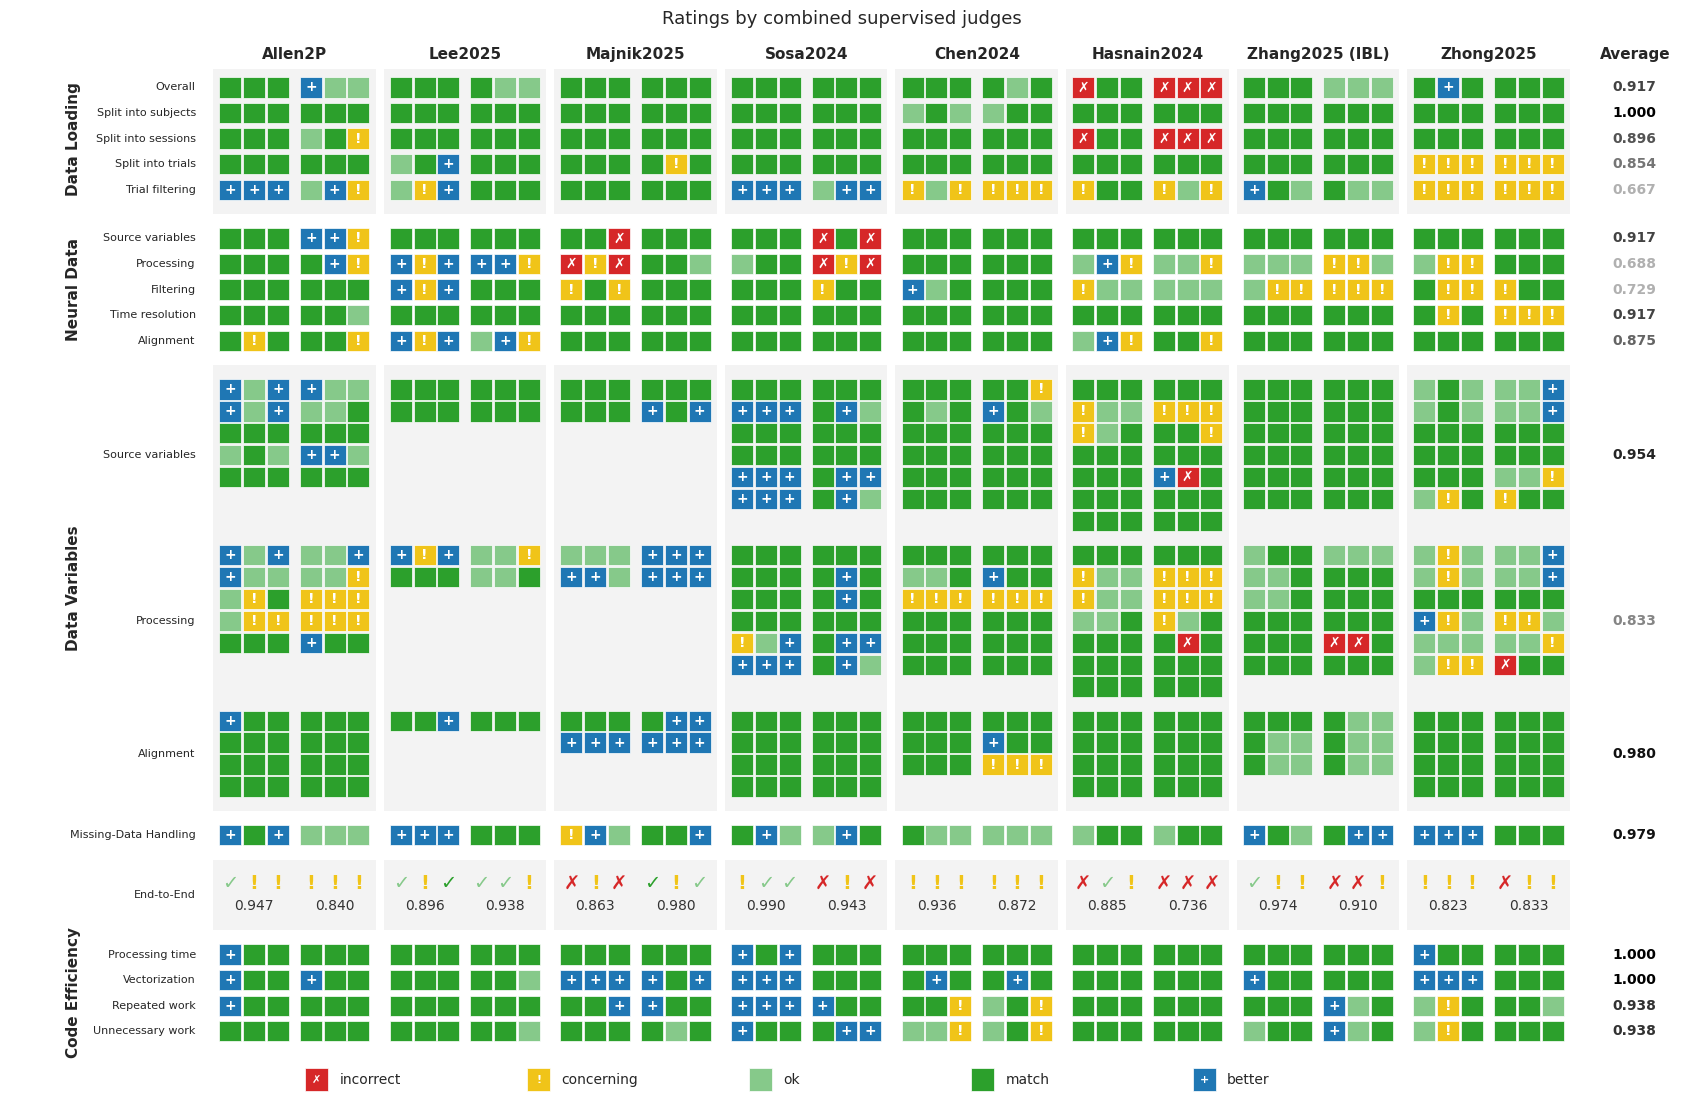

In [ ]:
NEW_CONDITIONS = [f"{a}/{p}" for a, p in NEW_ARMS]
tidy = add_combined(load_condition_ratings(datasets=DATASET_ORDER, conditions=NEW_ARMS).tidy)

# same variables left out as the paper's figure (ratings_analysis.ipynb)
EXCLUDE_VARS = {
    "sosa2024": ("input: Environment type", "input: Trial number", "output: Reward outcome"),
    "zhong2025": ("input: reward_availability", "output: licking"),
}
fig, _ = summary_table(conditions.condition_nested(tidy, NEW_CONDITIONS), 
                       rater="combined", exclude_variables=EXCLUDE_VARS)
# fig.savefig('./Rating_new_models.pdf', bbox_inches='tight', dpi=300)
plt.show()